In [ ]:
# Install necessary libraries
!pip install pandas beautifulsoup4 unidecode
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install nltk
!pip install scikit-learn matplotlib
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 2.6 MB/s eta 0:00:00
2023-12-15 13:24:38.936746: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-15 13:24:38.936809: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-15 13:24:38.937979: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-15 13:24:38.943528: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the

In [ ]:
import numpy as np
import pandas as pd
import nltk
import seaborn as sns
import spacy
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from unidecode import unidecode
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [ ]:
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df = pd.read_csv('/content/mail_data.csv')
# Print the first few rows of the DataFrame
print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
# Function to remove HTML tags using BeautifulSoup
def remove_html_tags(text):
    soup = BeautifulSoup(text, 'html.parser')
    return soup.get_text()

# Function to remove accented characters using unidecode
def remove_accented_chars(text):
    return unidecode(text)

# Tokenization using spaCy
nlp = spacy.load('en_core_web_sm')
def tokenize_text(text):
    doc = nlp(text)
    return [token.text for token in doc]

# Remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return ' '.join(filtered_tokens)

# Lemmatization using spaCy
def process_text(text):
    doc = nlp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if token.text.lower() not in stop_words]
    return ' '.join(lemmatized_tokens)


# Apply the functions to the relevant columns in your dataset
df['Message'] = df['Message'].apply(remove_html_tags)
df['Message'] = df['Message'].apply(remove_accented_chars)
df['Tokens'] = df['Message'].apply(tokenize_text)
df['Message'] = df['Message'].apply(remove_stopwords)
df['Message'] = df['Message'].apply(process_text)

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Message'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

df = pd.concat([df, tfidf_df], axis=1)

<ipython-input-5-a40eea08969b>:3: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser')


In [ ]:
df.to_csv('/content/cleaned_mail_data.csv', index=False)

# Load the cleaned dataset
data = pd.read_csv('/content/cleaned_mail_data.csv')

In [ ]:
data = pd.read_csv('/content/cleaned_mail_data.csv')
mail_data = df.where(pd.notnull(df), '')

mail_data.head()
mail_data.shape

(5572, 5003)

In [ ]:
# Map 'spam' to 0 and 'ham' to 1
df['Category'] = df['Category'].map({'spam': 0, 'ham': 1})

In [ ]:
# Separating the data as text and labels
X = df['Message']
Y = df['Category']
print(X)
print(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.6, random_state=3)

print(X.shape)
print(X_train.shape)
print(X_test.shape)

0       go jurong point , crazy .. available bugis n g...
1                           ok lar ... joke wif u oni ...
2       free entry 2 wkly comp win FA Cup final tkts 2...
3             u dun say early hor ... u c already say ...
4               Nah not think go usf , live around though
                              ...                        
5567    2nd time try 2 contact u. U PS750 Pound prize ...
5568                           u b go esplanade fr home ?
5569                     pity , * mood . ... suggestion ?
5570    guy bitching act like have interested buy some...
5571                                     rofl . true name
Name: Message, Length: 5572, dtype: object
0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: int64
(5572,)
(2228,)
(3344,)


In [ ]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)


Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

print(X_train_features)


  (0, 3082)	0.7252097810545557
  (0, 2875)	0.6885279758025837
  (1, 577)	0.44763773451502736
  (1, 1089)	0.25062530229874946
  (1, 4300)	0.35792999563688416
  (1, 3929)	0.26558064691914696
  (1, 3764)	0.5187294355881984
  (1, 3558)	0.5187294355881984
  (2, 515)	1.0
  (3, 2156)	0.4249985908827661
  (3, 3448)	0.441694513610387
  (3, 1225)	0.2739488382797819
  (3, 1121)	0.4652260950399354
  (3, 2288)	0.40146700945321756
  (3, 4102)	0.22431625690683163
  (3, 1080)	0.3482891415206572
  (4, 2292)	0.26388285467718425
  (4, 1389)	0.4057948080339113
  (4, 2683)	0.2918297185319637
  (4, 4209)	0.26704776563341026
  (4, 256)	0.3296552710589331
  (4, 146)	0.300529137205146
  (4, 3666)	0.4057948080339113
  (4, 1444)	0.28440834469321247
  (4, 608)	0.4057948080339113
  :	:
  (2225, 1865)	0.34554115102860156
  (2225, 2737)	0.2803973355336153
  (2226, 3360)	0.35179585671208613
  (2226, 1463)	0.3448502667311302
  (2226, 1338)	0.3692973456849267
  (2226, 2320)	0.3237601370084353
  (2226, 4036)	0.292232189

In [ ]:
# Training the model
model = LogisticRegression()
model.fit(X_train_features, Y_train)

prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data)
print('Accuracy on the training data:', accuracy_on_training_data)

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(Y_test, prediction_on_test_data)
print('Accuracy on the test data:', accuracy_on_test_data)

Accuracy on the training data: 0.9483842010771992
Accuracy on the test data: 0.9392942583732058


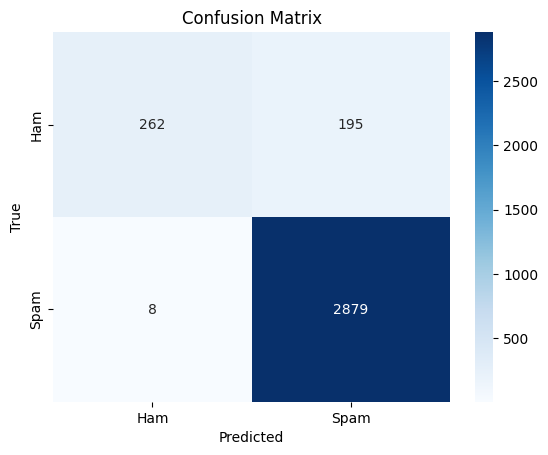

In [ ]:
# Evaluate the model and plot the confusion matrix
cm = confusion_matrix(Y_test, prediction_on_test_data)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Example: Predict whether a new email is spam or ham
user_input_email = input("Enter the new email text: ")
input_mail = [user_input_email]
input_mail_features = feature_extraction.transform(input_mail)

# Predict using the trained model
prediction = model.predict(input_mail_features)

# Display the prediction
print("Prediction for the new email:")
if prediction[0] == 1:
    print("Ham Mail")
else:
    print("Spam Mail")

Enter the new email text: "URGENT! Your Mobile No. was awarded £2000 Bonus Caller Prize on 5/9/03 This is our final try to contact U! Call from Landline 09064019788 BOX42WR29C, 150PPM"
Prediction for the new email:
Spam Mail
